In [1]:
!nvidia-smi

Thu Oct  8 14:50:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [3]:
!pip install -q numpy pandas scikit-learn

In [4]:
%cd /content/IEMOCAP

!python inference.py --load_model_state_dir ECERC_MODEL.pkl

/content/IEMOCAP
Running on GPU
The model have 5975310 paramerters in total
Running on the multi features........
test_loss: 4.8891, test_acc: 71.6, test_fscore: 71.77, time: 0.76 sec
              precision    recall  f1-score   support

         hap     0.5449    0.6736    0.6025       144
         sad     0.7860    0.7796    0.7828       245
         neu     0.7052    0.7474    0.7257       384
         ang     0.6534    0.6765    0.6647       170
         exc     0.8415    0.7458    0.7908       299
         fru     0.7034    0.6535    0.6776       381

    accuracy                         0.7160      1623
   macro avg     0.7057    0.7127    0.7073      1623
weighted avg     0.7224    0.7160    0.7177      1623

[[ 97   2  15   0  29   1]
 [  3 191  24   2   0  25]
 [ 24  24 287   5   8  36]
 [  0   3  13 115   0  39]
 [ 53   4  13   2 223   4]
 [  1  19  55  52   5 249]]


In [5]:
!python inference.py --load_model_state_dir ECERC_MODEL_2.pkl

Running on GPU
The model have 5975310 paramerters in total
Running on the multi features........
test_loss: 4.9278, test_acc: 71.53, test_fscore: 71.78, time: 0.34 sec
              precision    recall  f1-score   support

         hap     0.5187    0.6736    0.5861       144
         sad     0.8122    0.8122    0.8122       245
         neu     0.7411    0.7083    0.7244       384
         ang     0.6464    0.6882    0.6667       170
         exc     0.8226    0.7291    0.7730       299
         fru     0.6825    0.6772    0.6798       381

    accuracy                         0.7153      1623
   macro avg     0.7039    0.7148    0.7070      1623
weighted avg     0.7235    0.7153    0.7178      1623

[[ 97   1  10   0  34   2]
 [  4 199  16   2   0  24]
 [ 27  23 272   7   8  47]
 [  0   2   8 117   0  43]
 [ 58   4  13   2 218   4]
 [  1  16  48  53   5 258]]


In [6]:
%%bash
cd /content/IEMOCAP
OUT=./contrastive_final
declare -A CFG
CFG[P1]="--lambda_con 0 --lambda_pair 1.0"
CFG[P2]="--lambda_con 0 --lambda_pair 2.0"
CFG[P4]="--lambda_con 0 --lambda_pair 4.0"
CFG[PC]="--lambda_con 1.0 --lambda_pair 2.0 --margin 0.4 --proto_weight 0.2"

for S in 1 2 3 4 5; do
  python train_con2.py --seed $S --lambda_con 0 --lambda_pair 0 --output_dir $OUT --tag CTRL_s$S | tail -n 2
  for K in P1 P2 P4 PC; do
    python train_con2.py --seed $S ${CFG[$K]} --output_dir $OUT --tag ${K}_s$S | tail -n 2
  done
done

hap<->exc errors: 84, ang<->fru errors: 100
Saved to ./contrastive_final
hap<->exc errors: 80, ang<->fru errors: 94
Saved to ./contrastive_final
hap<->exc errors: 86, ang<->fru errors: 90
Saved to ./contrastive_final
hap<->exc errors: 76, ang<->fru errors: 93
Saved to ./contrastive_final
hap<->exc errors: 81, ang<->fru errors: 92
Saved to ./contrastive_final
hap<->exc errors: 89, ang<->fru errors: 100
Saved to ./contrastive_final
hap<->exc errors: 90, ang<->fru errors: 97
Saved to ./contrastive_final
hap<->exc errors: 81, ang<->fru errors: 98
Saved to ./contrastive_final
hap<->exc errors: 76, ang<->fru errors: 92
Saved to ./contrastive_final
hap<->exc errors: 82, ang<->fru errors: 96
Saved to ./contrastive_final
hap<->exc errors: 71, ang<->fru errors: 101
Saved to ./contrastive_final
hap<->exc errors: 70, ang<->fru errors: 98
Saved to ./contrastive_final
hap<->exc errors: 69, ang<->fru errors: 104
Saved to ./contrastive_final
hap<->exc errors: 71, ang<->fru errors: 100
Saved to ./contr

In [7]:
import numpy as np
from sklearn.metrics import f1_score
OUT = './contrastive_final'

def load(tag, s):
    d = np.load(f'{OUT}/preds_{tag}_s{s}.npz'); cm = np.load(f'{OUT}/confusion_{tag}_s{s}.npy')
    l, p = d['labels'], d['preds']
    return [f1_score(l,p,average='weighted')*100, f1_score(l,p,average='macro')*100,
            cm[0,4]+cm[4,0], cm[3,5]+cm[5,3]]

res = {}
for g in ['CTRL','P1','P2','P4','PC']:
    a = np.array([load(g,s) for s in range(1,6)]); res[g] = a
    t = a[:,2]+a[:,3]
    print(f"{g:5s} wF1 {a[:,0].mean():.2f}  mF1 {a[:,1].mean():.2f}  hap<->exc {a[:,2].mean():.1f}  "
          f"ang<->fru {a[:,3].mean():.1f}  total {t.mean():.1f}±{t.std():.1f}")

# winner = lowest mean pair errors among regularized configs, with macro-F1 not more than 1.0 below CTRL
ok = {g: (res[g][:,2]+res[g][:,3]).mean() for g in ['P1','P2','P4','PC']
      if res[g][:,1].mean() >= res['CTRL'][:,1].mean() - 1.0}
win = min(ok, key=ok.get) if ok else 'P1'
open(f'{OUT}/winner.txt','w').write(win)
print('WINNER:', win)

CTRL  wF1 69.55  mF1 68.70  hap<->exc 81.2  ang<->fru 100.4  total 181.6±5.6
P1    wF1 69.80  mF1 68.83  hap<->exc 78.4  ang<->fru 96.6  total 175.0±6.6
P2    wF1 69.47  mF1 68.68  hap<->exc 75.4  ang<->fru 96.2  total 171.6±7.2
P4    wF1 69.15  mF1 68.35  hap<->exc 72.6  ang<->fru 94.4  total 167.0±5.1
PC    wF1 69.48  mF1 68.73  hap<->exc 73.0  ang<->fru 94.6  total 167.6±11.2
WINNER: P4


In [8]:
%%bash
cd /content/ECERC/IEMOCAP
OUT=./contrastive_final
declare -A CFG
CFG[P1]="--lambda_con 0 --lambda_pair 1.0"
CFG[P2]="--lambda_con 0 --lambda_pair 2.0"
CFG[P4]="--lambda_con 0 --lambda_pair 4.0"
CFG[PC]="--lambda_con 1.0 --lambda_pair 2.0 --margin 0.4 --proto_weight 0.2"
WIN=$(cat $OUT/winner.txt)
echo "Winner config: $WIN -> ${CFG[$WIN]}"

for S in 6 7 8 9 10 11 12 13 14 15; do
  python train_con2.py --seed $S --lambda_con 0 --lambda_pair 0 --output_dir $OUT --tag CTRL_s$S | tail -n 2
  python train_con2.py --seed $S ${CFG[$WIN]} --output_dir $OUT --tag ${WIN}_s$S | tail -n 2
done

# ensembles (separate rows in the report)
python ensemble.py "$OUT/probs_CTRL_s*.npy"   $OUT/preds_CTRL_s1.npz
python ensemble.py "$OUT/probs_${WIN}_s*.npy" $OUT/preds_${WIN}_s1.npz

Winner config: P4 -> --lambda_con 0 --lambda_pair 4.0
hap<->exc errors: 81, ang<->fru errors: 96
Saved to ./contrastive_final
hap<->exc errors: 75, ang<->fru errors: 99
Saved to ./contrastive_final
hap<->exc errors: 95, ang<->fru errors: 93
Saved to ./contrastive_final
hap<->exc errors: 104, ang<->fru errors: 95
Saved to ./contrastive_final
hap<->exc errors: 79, ang<->fru errors: 99
Saved to ./contrastive_final
hap<->exc errors: 81, ang<->fru errors: 97
Saved to ./contrastive_final
hap<->exc errors: 79, ang<->fru errors: 93
Saved to ./contrastive_final
hap<->exc errors: 76, ang<->fru errors: 95
Saved to ./contrastive_final
hap<->exc errors: 63, ang<->fru errors: 99
Saved to ./contrastive_final
hap<->exc errors: 83, ang<->fru errors: 92
Saved to ./contrastive_final
hap<->exc errors: 76, ang<->fru errors: 91
Saved to ./contrastive_final
hap<->exc errors: 75, ang<->fru errors: 87
Saved to ./contrastive_final
hap<->exc errors: 74, ang<->fru errors: 94
Saved to ./contrastive_final
hap<->exc

bash: line 1: cd: /content/ECERC/IEMOCAP: No such file or directory


model                  acc     wF1     mF1     hap<->exc  ang<->fru  total
Authors                71.60   71.78   70.82   87.0       93.5       180.5
Ours CTRL (10 seeds)   69.61   69.79   68.92   77.3±7.6  96.6±3.6  173.9±7.1
Ours P4 (10 seeds)     69.48   69.63   68.49   79.0±9.0  95.3±3.4  174.3±9.1
P4 vs CTRL total pair errors: +0.4, fewer in 6/10 seeds


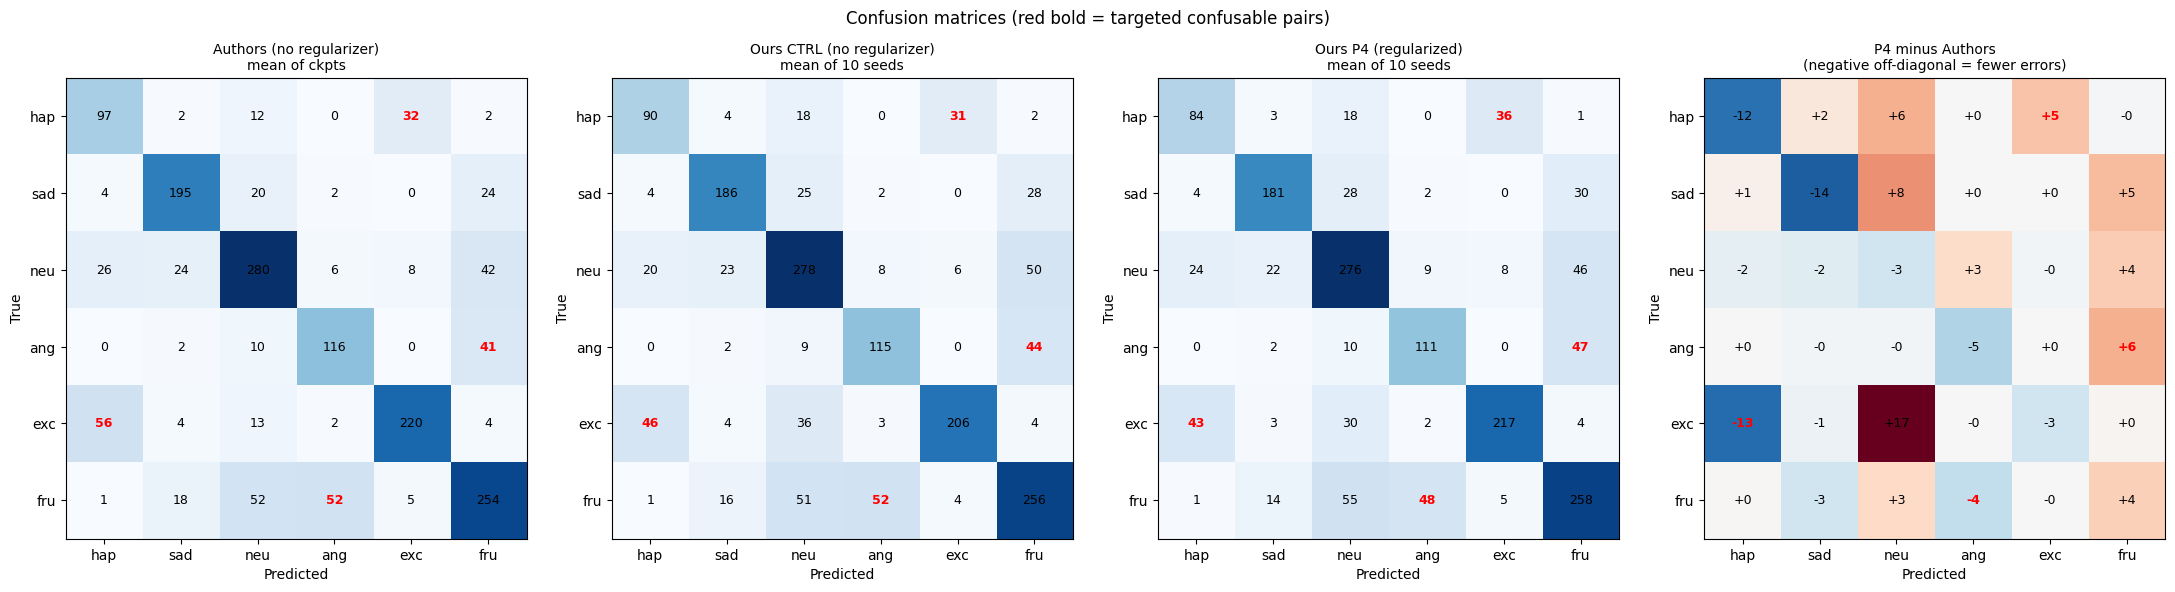


Ensemble CTRL  hap<->exc 80  ang<->fru 95
[[ 89   4  18   0  31   2]
 [  4 189  25   2   0  25]
 [ 22  22 279   8   7  46]
 [  0   2  10 116   0  42]
 [ 49   4  36   3 203   4]
 [  1  14  53  53   5 255]]

Ensemble P4  hap<->exc 74  ang<->fru 91
[[ 87   4  19   0  33   1]
 [  4 184  26   2   0  29]
 [ 25  20 279   9   7  44]
 [  0   3  11 112   0  44]
 [ 41   3  33   2 216   4]
 [  1  14  57  47   5 257]]


In [10]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

OUT = './contrastive_final'
WIN = open(f'{OUT}/winner.txt').read().strip()
names = ['hap','sad','neu','ang','exc','fru']

# Use only the first 2 author confusion matrices
authors = np.array([
    [[97,2,15,0,29,1],
     [3,191,24,2,0,25],
     [24,24,287,5,8,36],
     [0,3,13,115,0,39],
     [53,4,13,2,223,4],
     [1,19,55,52,5,249]],

    [[97,1,10,0,34,2],
     [4,199,16,2,0,24],
     [27,23,272,7,8,47],
     [0,2,8,117,0,43],
     [58,4,13,2,218,4],
     [1,16,48,53,5,258]]
])

A = authors.mean(0)

pair = lambda cm: (
    cm[0,4] + cm[4,0],
    cm[3,5] + cm[5,3]
)

def runs(tag, seeds):
    cms, f1, mf, acc = [], [], [], []

    for s in seeds:
        d = np.load(f'{OUT}/preds_{tag}_s{s}.npz')
        l, p = d['labels'], d['preds']

        cms.append(confusion_matrix(l, p))
        acc.append(accuracy_score(l, p) * 100)
        f1.append(f1_score(l, p, average='weighted') * 100)
        mf.append(f1_score(l, p, average='macro') * 100)

    return np.array(cms), np.array(acc), np.array(f1), np.array(mf)


seeds = range(6, 16)   # confirmation seeds only

C_cm, C_acc, C_f1, C_mf = runs('CTRL', seeds)
W_cm, W_acc, W_f1, W_mf = runs(WIN, seeds)


print(f"{'model':22s} acc     wF1     mF1     hap<->exc  ang<->fru  total")

# Authors: now mean of 2 checkpoints
a_pairs = [pair(m) for m in authors]

print(
    f"{'Authors ':22s} "
    f"71.60   71.78   70.82   "
    f"{np.mean([p[0] for p in a_pairs]):.1f}       "
    f"{np.mean([p[1] for p in a_pairs]):.1f}       "
    f"{np.mean([sum(p) for p in a_pairs]):.1f}"
)

for nm, cm, acc, f1, mf in [
    ('Ours CTRL (10 seeds)', C_cm, C_acc, C_f1, C_mf),
    (f'Ours {WIN} (10 seeds)', W_cm, W_acc, W_f1, W_mf)
]:
    pp = np.array([pair(m) for m in cm])

    print(
        f"{nm:22s} "
        f"{acc.mean():.2f}   "
        f"{f1.mean():.2f}   "
        f"{mf.mean():.2f}   "
        f"{pp[:,0].mean():.1f}±{pp[:,0].std():.1f}  "
        f"{pp[:,1].mean():.1f}±{pp[:,1].std():.1f}  "
        f"{pp.sum(1).mean():.1f}±{pp.sum(1).std():.1f}"
    )

d = np.array([
    sum(pair(w)) - sum(pair(c))
    for w, c in zip(W_cm, C_cm)
])

print(
    f"{WIN} vs CTRL total pair errors: "
    f"{d.mean():+.1f}, fewer in {(d < 0).sum()}/10 seeds"
)


# Confusion-matrix figure
Wm, Cm = W_cm.mean(0), C_cm.mean(0)

panels = [
    ('Authors (no regularizer)\nmean of ckpts', A, 'Blues', None),
    ('Ours CTRL (no regularizer)\nmean of 10 seeds', Cm, 'Blues', None),
    (f'Ours {WIN} (regularized)\nmean of 10 seeds', Wm, 'Blues', None),
    (f'{WIN} minus Authors\n(negative off-diagonal = fewer errors)', Wm-A, 'RdBu_r', 'diff')
]

fig, ax = plt.subplots(1, 4, figsize=(22, 5.5))

for a_, (title, M, cmap, kind) in zip(ax, panels):
    v = np.abs(M).max() if kind else None

    a_.imshow(
        M,
        cmap=cmap,
        vmin=-v if v else None,
        vmax=v
    )

    a_.set_xticks(range(6))
    a_.set_yticks(range(6))
    a_.set_xticklabels(names)
    a_.set_yticklabels(names)

    a_.set_xlabel('Predicted')
    a_.set_ylabel('True')
    a_.set_title(title, fontsize=10)

    for i in range(6):
        for j in range(6):
            hi = (i, j) in [
                (0, 4), (4, 0),
                (3, 5), (5, 3)
            ]

            a_.text(
                j, i,
                f'{M[i,j]:+.0f}' if kind else f'{M[i,j]:.0f}',
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold' if hi else 'normal',
                color='red' if hi else 'black'
            )

plt.suptitle(
    'Confusion matrices (red bold = targeted confusable pairs)',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    f'{OUT}/confusion_comparison.png',
    dpi=200,
    bbox_inches='tight'
)
plt.show()


# Ensemble confusion matrix (all seeds) for reference
import glob

def ens_cm(tag):
    probs = np.mean(
        [
            np.load(f)
            for f in sorted(
                glob.glob(f'{OUT}/probs_{tag}_s*.npy')
            )
        ],
        0
    )

    l = np.load(
        f'{OUT}/preds_{tag}_s1.npz'
    )['labels']

    return confusion_matrix(
        l,
        probs.argmax(1)
    )


for tag in ['CTRL', WIN]:
    m = ens_cm(tag)

    print(
        f'\nEnsemble {tag}  '
        f'hap<->exc {pair(m)[0]}  '
        f'ang<->fru {pair(m)[1]}\n'
        f'{m}'
    )